In [1]:
import sys
import atexit
from pyaedt import *
import pyaedt
import subprocess
import psutil
import shutil
from datetime import datetime
import numpy as np
import pandas as pd
from pyaedt.application.Variables import Variable
from scipy.stats import qmc
from datetime import datetime
from IPython.display import clear_output
import matplotlib.pyplot as plt

In [2]:
pname_code2data = {
    "h_subs":"height of substrate",
    "l_patch":"length of patch",
    "w_patch":"width of patch",
    "h_patch":"height of patch",
    "h_sr":"height of solder resist layer",
    "r_probe":"radius of the probe",
    "c_pad":"c_pad",
    "c_antipad":"c_antipad",
    "c_probe":"c_probe",
    "$e1":"dielectric constant of substrate",
    "$e2":"dielectric constant of solder resist layer",
}
pname_data2code = {v:k for k,v in pname_code2data.items()}

In [3]:
input_boundaries = {'length of patch': {'min': 1.8, 'max': 5.2},
 'width of patch': {'min': 1.8, 'max': 5.2},
 'height of patch': {'min': 0.01, 'max': 0.04},
 'height of substrate': {'min': 0.1, 'max': 0.8},
 'height of solder resist layer': {'min': 0.02, 'max': 0.1},
 'radius of the probe': {'min': 0.015, 'max': 0.05},
 'c_pad': {'min': 0.0, 'max': 0.025},
 'c_antipad': {'min': 0.025, 'max': 0.1},
 'c_probe': {'min': 0.05, 'max': 0.45},
 'dielectric constant of substrate': {'min': 2.0, 'max': 5.0},
 'dielectric constant of solder resist layer': {'min': 2.0, 'max': 5.0}}
input_boundaries_np = pd.DataFrame(input_boundaries).values

input_min = input_boundaries_np[0]
input_max = input_boundaries_np[1]
input_range = input_max - input_min



n0 = 20
n_seed = 5
N = 120
n_new = N-n0

times = {}

Seed: 4/5	Obs: 19/20
Run time: (19, datetime.timedelta(seconds=79, microseconds=930188))
Seed time: 2003.341408
Total time: 10500.049929


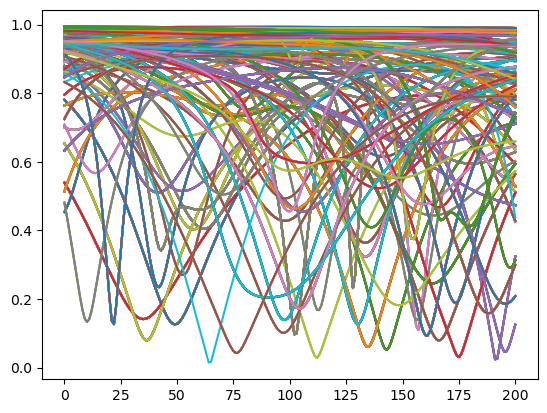

In [4]:
total_time = datetime.now()
for lhs_seed in range(n_seed):
    input_trials_done = pd.DataFrame(columns = np.array(list(input_boundaries.keys())))
    real_initial = pd.DataFrame()
    imag_initial = pd.DataFrame()
    sampler = qmc.LatinHypercube(d=11,seed=lhs_seed) #seed=1
    sample = sampler.random(n=n0)
    #sample = sample.round(1)
    lhs_input_trials =pd.DataFrame(input_min + sample*input_range,columns=input_trials_done.columns)
    lhs_input_trials.columns = lhs_input_trials.columns.map(pname_data2code)
    lhs_input_trials = lhs_input_trials.round(3)
    lhs_input_trials["c_probe"] =   round(lhs_input_trials["c_probe"]   ,2)
    lhs_input_trials["$e1"] =       round(lhs_input_trials["$e1"]       ,2)
    lhs_input_trials["$e2"] =       round(lhs_input_trials["$e2"]       ,2)

    lhs_input_trials.columns = lhs_input_trials.columns.map(pname_code2data)
    lhs_input_trials

    input_trials_done = pd.DataFrame(columns = np.array(list(input_boundaries.keys())))
    real_initial = pd.DataFrame()
    imag_initial = pd.DataFrame()
    seed_time = datetime.now()
    datafile_suffix = f"LHS_n{n0}_rounded_seed"+str(lhs_seed).zfill(3)
    times[lhs_seed] = {}
    for obs in range(len(lhs_input_trials)):
        aedt_original_filename = "sevenmodel_groundport_870.aedt"
        aedt_original_filepath = "../"+aedt_original_filename
        aedt_current_filename = f"LHS_n{n0}_rounded_seed"+str(lhs_seed).zfill(3)+"_config"+str(obs).zfill(3)+".aedt"
        aedt_current_filepath = "aedt_files/"+aedt_current_filename
        shutil.copy(aedt_original_filepath,aedt_current_filepath)
        hfss = Hfss(aedt_current_filepath)
        hfss.save_project()

        varMan = hfss.variable_manager
        param_units = {k:varMan.variables[k].units for k in varMan.variables.keys()}

        start_time = datetime.now()
        test_parameters = lhs_input_trials.iloc[obs]
        test_parameters.index = test_parameters.index.map(pname_data2code)
        test_parameters = test_parameters.to_dict()

        print(test_parameters)

        for k,v in test_parameters.items():
            # varMan[k] = Variable(v,units=param_units[k])
            varMan.set_variable(k,expression = f"{v}{param_units[k]}")
            # print(v,param_units[k])

        hfss.save_project()
        hfss.analyze()
        hfss.save_project()

        var_name = hfss.get_traces_for_plot(category="S")
        sol_data = hfss.post.get_solution_data(var_name)
        real_part = list(sol_data._solutions_real[var_name[0]].values())
        imag_part = list(sol_data._solutions_imag[var_name[0]].values())
        real_part = np.array(real_part)
        imag_part =  np.array(imag_part)



        tp_to_save = pd.DataFrame([test_parameters])
        tp_to_save.columns = tp_to_save.columns.map(pname_code2data)


        input_trials_done = pd.concat([input_trials_done,tp_to_save],axis = 0)
        real_initial = pd.concat([real_initial,pd.DataFrame([real_part])],axis=0)
        imag_initial = pd.concat([imag_initial,pd.DataFrame([imag_part])],axis=0)

        input_trials_done.to_csv(f"input_trials_done_{datafile_suffix}.csv",index=None)
        real_initial.to_csv(f"real_initial_{datafile_suffix}.csv",index=None)
        imag_initial.to_csv(f"imag_initial_{datafile_suffix}.csv",index=None)
        hfss.close_desktop()
        clear_output(wait=True)
        mag = (real_initial**2+imag_initial**2)**.5
        times[lhs_seed][obs] = obs,datetime.now()-start_time
        print(f"Seed: {lhs_seed}/{n_seed}\tObs: {obs}/{n0}")
        print(f"Run time: {times[lhs_seed][obs]}")
        print(f"Seed time: {(datetime.now()-seed_time).total_seconds()}")
        print(f"Total time: {(datetime.now()-total_time).total_seconds()}")
        plt.plot(mag.T)
        plt.show()